In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import torch

from moc_repro import (
    BenchmarkConfig,
    ModelConfig,
    TrainConfig,
    benchmark_dense_vs_moc,
    prepare_contiguous_lm_data,
    run_pair_training,
    summarize_histories,
    validate_hybrid_topk_moc,
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [2]:
dataset = prepare_contiguous_lm_data(
    source_name='wikitext2_raw',
    tokenizer_name='hf-internal-testing/llama-tokenizer',
    cache_dir='data',
)

model_config = ModelConfig(
    vocab_size=dataset.vocab_size,
    block_size=512,
    n_layer=6,
    n_head=8,
    n_embd=384,
    intermediate_size=1024,
    dropout=0.0,
)

train_config = TrainConfig(
    batch_size=8,
    block_size=512,
    steps=60,
    learning_rate=3e-4,
    eval_interval=15,
    eval_batches=4,
    seed=42,
)

benchmark_config = BenchmarkConfig(
    block_sizes=(256, 512, 1024, 2048),
    batch_size=4,
    steps=8,
    learning_rate=3e-4,
    seed=42,
)

dataset

TextDataset(name='wikitext2_raw', tokenizer_name='hf-internal-testing/llama-tokenizer', text_path=PosixPath('data/wikitext2_raw.txt'), train_tokens=array([    1, 29871,    13, ...,   450,  9338, 29909]), val_tokens=array([ 5492,   278,  6666, ...,    13, 29871,    13]), vocab_size=32001)

In [3]:
validation = validate_hybrid_topk_moc(device=device.type, shape=(2, 4, 32), k_active=8)
validation

ValidationResult(max_forward_abs_diff=0.0, max_grad_g_abs_diff=2.384185791015625e-07, max_grad_u_abs_diff=2.384185791015625e-07)

In [4]:
pair_runs = run_pair_training(
    dataset=dataset,
    model_config=model_config,
    train_config=train_config,
    sparsity_ratio=0.75,
    use_checkpoint=False,
    device=device,
)

history_df = pd.DataFrame(summarize_histories(pair_runs))
history_df

,model,step,train_loss,val_loss,batch_size,block_size,steps,learning_rate,eval_interval,eval_batches,seed,elapsed_sec,tokens_per_sec,peak_memory_mb
0,dense,1,10.448710,10.173130,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,dense,15,8.489130,8.376333,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,dense,30,7.242672,7.180129,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,dense,45,6.945218,6.929564,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,dense,60,6.809166,6.724308,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,dense,summary,NaN,NaN,8.0,512.0,60.0,0.0003,15.0,4.0,42.0,14.764543,16645.283167,3118.143555
6,moc,1,10.428523,10.144178,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,moc,15,8.463430,8.353209,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,moc,30,7.230498,7.177609,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,moc,45,6.947875,6.934520,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
pair_runs

{'dense': {'history': [{'step': 1,
    'train_loss': 10.448710441589355,
    'val_loss': 10.17313003540039},
   {'step': 15,
    'train_loss': 8.489130020141602,
    'val_loss': 8.376332759857178},
   {'step': 30,
    'train_loss': 7.242672443389893,
    'val_loss': 7.180128812789917},
   {'step': 45,
    'train_loss': 6.945218086242676,
    'val_loss': 6.929564476013184},
   {'step': 60,
    'train_loss': 6.809165954589844,
    'val_loss': 6.724308490753174}],
  'summary': {'batch_size': 8,
   'block_size': 512,
   'steps': 60,
   'learning_rate': 0.0003,
   'eval_interval': 15,
   'eval_batches': 4,
   'seed': 42,
   'elapsed_sec': 14.764543056488037,
   'tokens_per_sec': 16645.283166552505,
   'peak_memory_mb': 3118.1435546875}},
 'moc': {'history': [{'step': 1,
    'train_loss': 10.428523063659668,
    'val_loss': 10.144177675247192},
   {'step': 15,
    'train_loss': 8.463430404663086,
    'val_loss': 8.353209018707275},
   {'step': 30,
    'train_loss': 7.230498313903809,
    'va

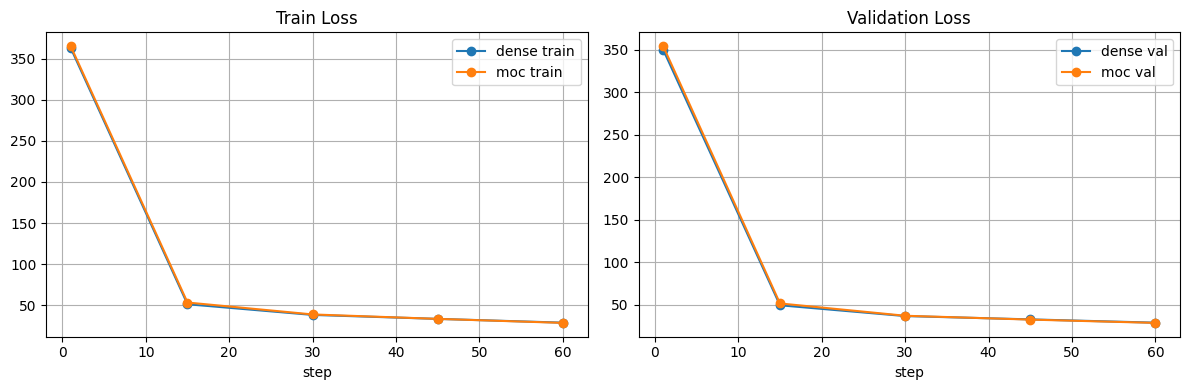

,model,step,train_loss,val_loss,batch_size,block_size,steps,learning_rate,eval_interval,eval_batches,seed,elapsed_sec,tokens_per_sec,peak_memory_mb
5,dense,summary,NaN,NaN,8.0,512.0,60.0,0.0003,15.0,4.0,42.0,14.547080,16894.112037,3118.143555
11,moc,summary,NaN,NaN,8.0,512.0,60.0,0.0003,15.0,4.0,42.0,14.402117,17064.158547,3108.171875


In [6]:
curve_df = history_df[history_df['step'] != 'summary'].copy()
curve_df['step'] = curve_df['step'].astype(int)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for model_name in ['dense', 'moc']:
    part = curve_df[curve_df['model'] == model_name]
    axes[0].plot(part['step'], part['train_loss'], marker='o', label=f'{model_name} train')
    axes[1].plot(part['step'], part['val_loss'], marker='o', label=f'{model_name} val')

axes[0].set_title('Train Loss')
axes[1].set_title('Validation Loss')
for ax in axes:
    ax.set_xlabel('step')
    ax.legend()
    ax.grid(True)
plt.tight_layout()
plt.show()

history_df[history_df['step'] == 'summary']

In [7]:
bench_rows = benchmark_dense_vs_moc(
    dataset=dataset,
    model_config=model_config,
    benchmark_config=benchmark_config,
    sparsity_ratio=0.75,
    use_checkpoint=False,
    device=device,
)

bench_df = pd.DataFrame(bench_rows)
bench_df

,model,block_size,status,tokens_per_sec,peak_memory_mb,final_train_loss,final_val_loss
0,dense,256,ok,15573.572031,995.498535,93.933830,81.099777
1,moc,256,ok,17273.995184,952.641113,102.097054,88.279633
2,dense,512,ok,18445.651277,1700.664062,106.878876,84.618118
3,moc,512,ok,17520.163316,1618.662598,114.225494,90.945190
4,dense,1024,ok,17837.215156,3121.268555,91.559113,70.635078
5,moc,1024,ok,17146.179085,2927.890625,98.309349,76.201202
6,dense,2048,ok,15877.797499,5955.471680,83.549965,75.458534
7,moc,2048,ok,15258.150011,5571.034180,88.401749,80.051750


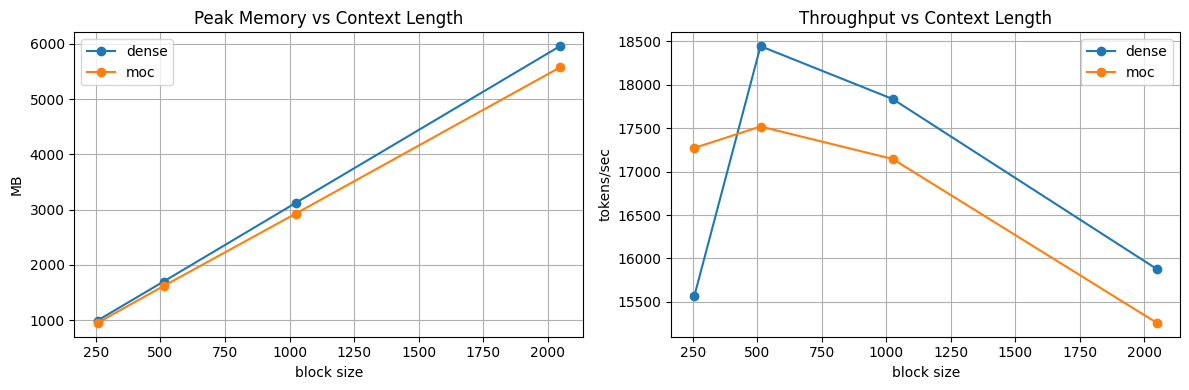

In [8]:
ok_df = bench_df[bench_df['status'] == 'ok']
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for model_name in ['dense', 'moc']:
    part = ok_df[ok_df['model'] == model_name]
    axes[0].plot(part['block_size'], part['peak_memory_mb'], marker='o', label=model_name)
    axes[1].plot(part['block_size'], part['tokens_per_sec'], marker='o', label=model_name)

axes[0].set_title('Peak Memory vs Context Length')
axes[1].set_title('Throughput vs Context Length')
axes[0].set_xlabel('block size')
axes[1].set_xlabel('block size')
axes[0].set_ylabel('MB')
axes[1].set_ylabel('tokens/sec')
for ax in axes:
    ax.legend()
    ax.grid(True)
plt.tight_layout()
plt.show()